# Set-up

## Load libraries

In [1]:
#Set directory
# install.packages("here")
library(here)
setwd(here())
#Install and load libraires
# invisible(source("./src/install_librairies.r"))
# install_packages(directory)
invisible(source("./src/load_librairies.r"))
# Load functions
invisible(source("./src/functions.r"))

here() starts at C:/Users/atanoh/Documents/2026/Surrogacy_evaluation_CA125


Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'reshape2'


L'objet suivant est masqué depuis 'package:tidyr':

    smiths



Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



A

## Load and clean dataset

In [2]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)


n_patients,n_trials,n_measures
<int>,<int>,<int>
8219,13,102809


In [3]:
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [4]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [5]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [6]:
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
8163,13,81449


In [7]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-factor(ifelse(ca125$os_status=='Yes', 1, 0), levels=c(0,1))
ca125["pfs_statut"]<-factor(ifelse(ca125$PFS_status=='Yes', 1, 0), levels=c(0,1))
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [8]:
ca125_all_6 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
7933,13,47256


**Summarise data**

In [9]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),

     # percentage deaths
    mean_baseline = round(mean(ca125_base, na.rm = TRUE),2),
    
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

trialid,status,nb_measures,nb_patients,mean_ca125,mean_baseline,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Maintenance,648,194,96.12,31.60,17.13,52.62,330.00,267.50
CCTG-OV.16,No maintenance,5517,731,222.35,721.71,72.05,84.74,1443.99,504.99
DoCaCel,Maintenance,40,19,186.32,346.38,72.50,77.50,995.50,374.50
EORTC-55041,Maintenance,1982,772,74.86,25.07,43.90,74.42,1351.00,424.00
GINECO-2007,Intensification therapy,613,109,313.07,870.53,83.85,92.50,975.00,445.00
JGOG-3016,Intensification therapy,3240,552,312.25,1022.00,46.57,65.25,1837.00,841.00
JGOG-3017,No maintenance,3497,608,67.62,129.05,18.84,26.19,1195.00,1100.00
MITO-7,Intensification therapy,1398,517,206.89,473.78,16.95,51.65,629.00,490.00
MRC-ICON7,Maintenance,10017,1471,113.08,376.65,46.14,71.46,1493.00,576.00


*Presentation of data and variables of interest (appendix)*

In [10]:
ca125_all_6 %>%  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

status,nb_measures,nb_patients,mean_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Intensification therapy,47256,7933,204.4,46.07,68.61,959,527


# Modeling CA125

## Evolution of CA-125

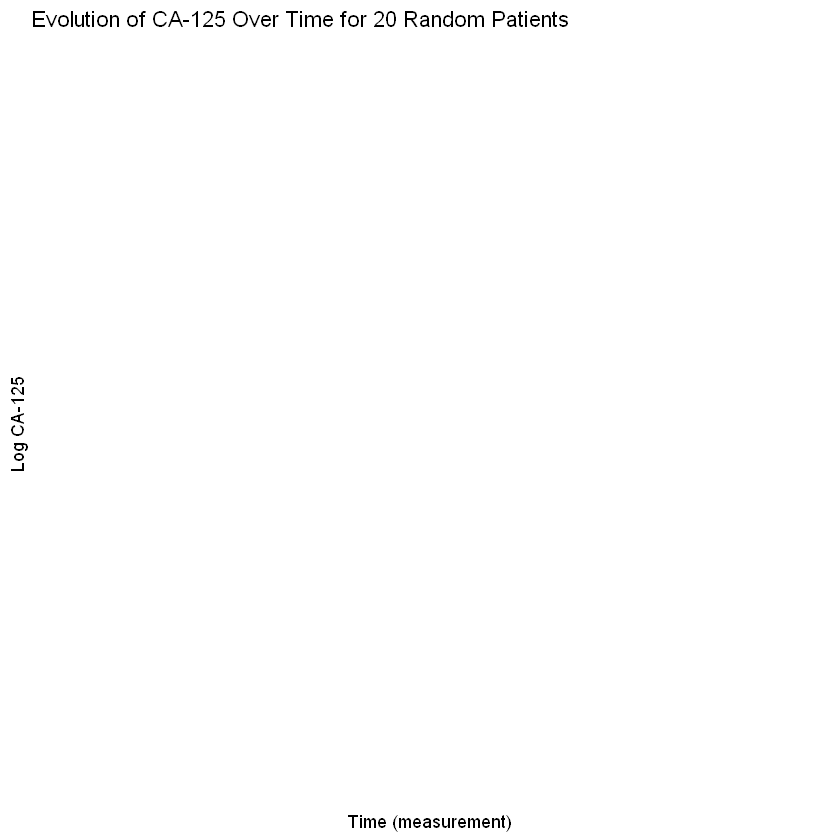

In [11]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [12]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)



decreasing increasing 
     43446       3810 

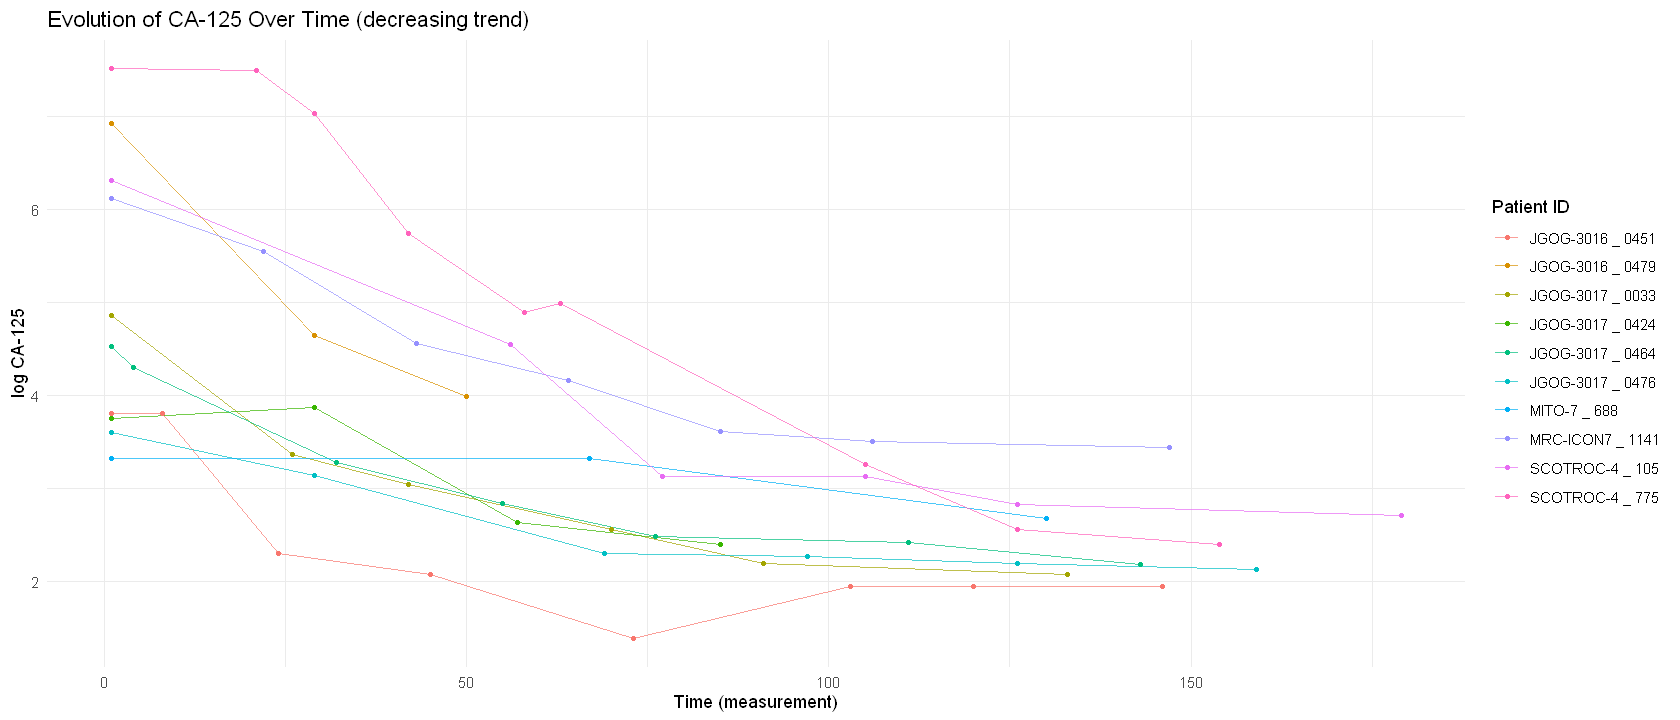

In [13]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

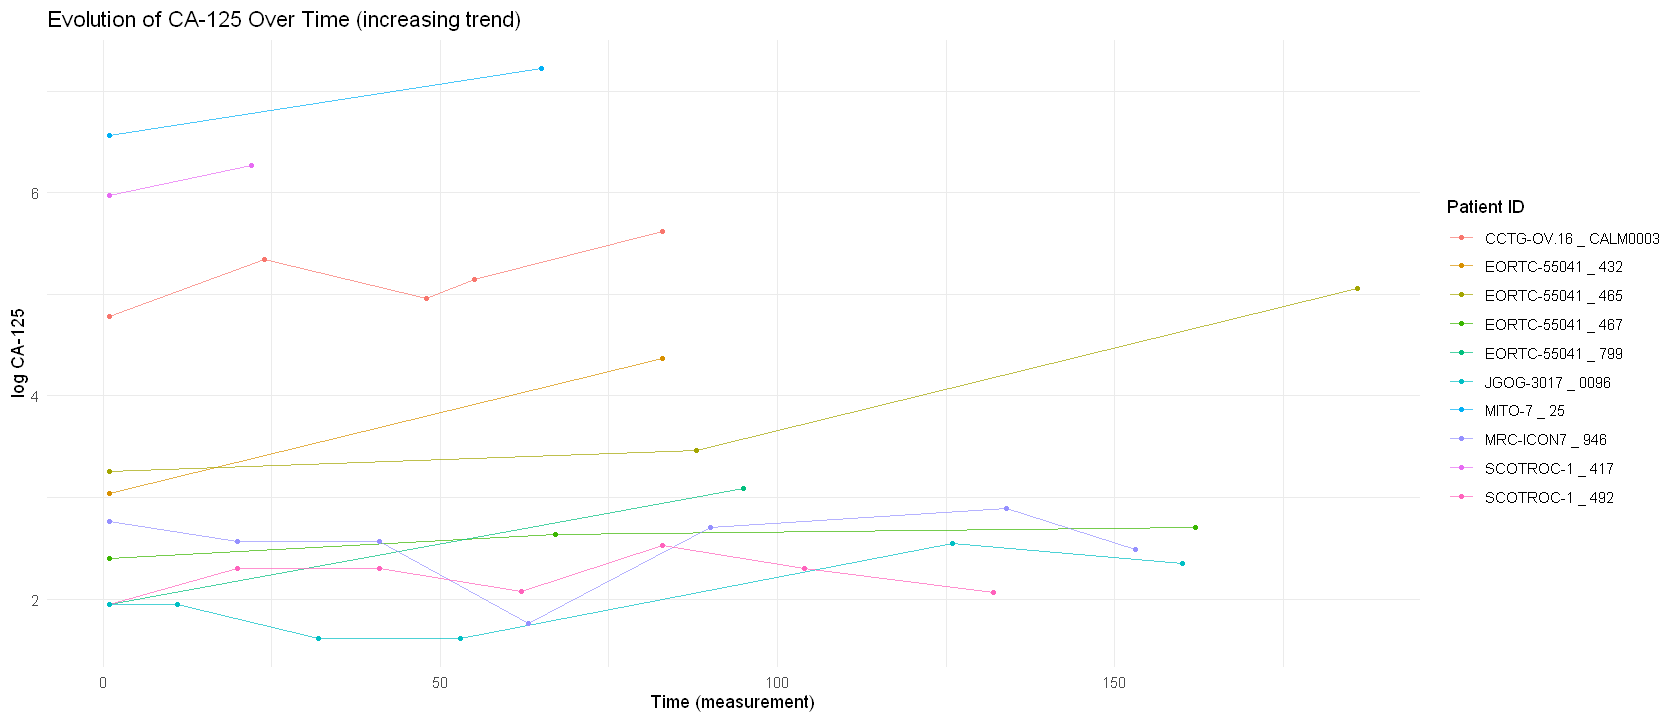

In [14]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

**Summarise CA-125 values**

In [15]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt) %>%
  
  summarise(
    
    n_measures = n(),
    n_patients = n_distinct(id),
    
    minca125 = min(CA125_mes, na.rm = TRUE),
    
    q1_ca125 = quantile(CA125_mes, 0.25, na.rm = TRUE),
    
    mean_ca125 = mean(CA125_mes, na.rm = TRUE),
    
    q3_ca125 = quantile(CA125_mes, 0.75, na.rm = TRUE),
    
    max_ca125 = max(CA125_mes, na.rm = TRUE),
        # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt)

trialid,trt,n_measures,n_patients,minca125,q1_ca125,mean_ca125,q3_ca125,max_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Investigational regimen,326,98,1.00,7.270,63.48276,27.675,3865.0,13.19018,56.74847,332.0001,265.9994
CCTG-OV.12,Standard regimen,322,96,0.60,7.000,129.15689,28.850,7027.0,21.11801,48.44720,327.9991,269.0005
CCTG-OV.16,Investigational regimen,2711,372,0.39,11.000,254.31692,128.000,12083.0,72.44559,85.06086,1457.9867,482.0083
CCTG-OV.16,Standard regimen,2806,359,0.21,11.000,191.45644,94.525,11800.0,71.66785,84.42623,1439.9981,524.0120
DoCaCel,Investigational regimen,16,8,7.00,9.000,126.43750,53.750,1046.0,62.50000,62.50000,791.0000,354.0000
DoCaCel,Standard regimen,24,11,9.00,11.000,226.25000,156.000,2100.0,79.16667,87.50000,1352.0000,374.5000
EORTC-55041,Investigational regimen,993,388,1.00,8.000,58.35952,23.000,3812.0,46.42497,76.33434,1340.0000,408.0000
EORTC-55041,Standard regimen,989,384,1.00,7.000,91.42568,23.000,14220.0,41.35490,72.49747,1372.0000,434.0000
GINECO-2007,Investigational regimen,292,48,4.00,16.000,253.08925,196.500,5180.0,86.98630,96.57534,1026.0000,490.0000


*Variables of interest per treatment group* 

# Joint modeling

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

## One model per trial



With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y_i$ in trial $i \in {1,...,s}$ :
$
log[y_i(t_{ijk})]= f_i(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f_i(t)= (\theta_{i1}+b_{1ij}) + (\theta_{i4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{ik+2}+ b_{k+2,ij})B_{k+2}(t)+ \theta_{i5}T_{ij}*t+ \sum_{k=0}^1 \theta_{ik+6} T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_{m_i})$


**Conditional BLUP for patient-level random effects**:

- $\theta_i=(\theta_{i1} \text{  } \theta_{i4} \text{  } \theta_{i2} \text{  } \theta_{i3} \text{  } \theta_{i5} \text{  } \theta_{i6} \text{  } \theta_{i7})^T$

Matricial form: $ y_i= X_i\theta_i + Z_{n_i}b_{n_i} + \epsilon_i$, with :
$
y_i =
\begin{pmatrix}
y(t_{i11}) \\
y(t_{i12}) \\
\vdots \\
y(t_{i1 m_{i1}}) \\
y(t_{i21}) \\
\vdots \\
y(t_{i n_i m_{in_im_i}})
\end{pmatrix}
\in \mathbb{R}^{m_i},
\qquad
$,
$
X_i =
\begin{pmatrix}
1 & t_{i11} & B_2(t_{i11}) & B_3(t_{i11}) & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11}) \\
1 & t_{i12} & B_2(t_{i12}) & B_3(t_{i12}) & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{i n_i m_i} & B_2(t_{i n_i m_i}) & B_3(t_{i n_i m_i}) & T_{in_i}*t_{i n_i m_i} & T_{in_i}*B_2(t_{i n_i m_i}) & T_{in_i}*B_3(t_{i n_i m_i})
\end{pmatrix}
\in \mathbb{R}^{m_i \times 7}
$
- $b_{n_i} \sim N(0, \Delta_i)$ (patient-level random intercept+slope), $
\Delta_i = \mathrm{diag}(D_i,...,D_i) \in \mathbb{R}^{4n_i \times 4n_i}
$

$$
b_{n_i} =
\begin{pmatrix}
b_{1,i1} \\
b_{4,i1} \\
b_{2,i1} \\
b_{3,i1} \\
b_{1,i2} \\
b_{4,i2} \\
b_{2,i2} \\
b_{3,i2} \\
\vdots \\
b_{1,i n_i} \\
b_{4,i n_i} \\
b_{2,i n_i}\\
b_{3,i n_i}
\end{pmatrix}
\in \mathbb{R}^{4n_i},
\qquad
$$

- $\epsilon_i \sim N(0, \sigma^2_{\epsilon}I_{m_i})$

$\boxed{Var(y_i)=V_i= Z_{n_i}\Delta_i Z_{n_i}^T + \sigma^2_{\epsilon}I_N}$\
with, for patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n_i} = \Delta_i Z_{n_i}^\top V_i^{-1}(y_i-X_i\hat{\theta_i})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V_i^{-1}(y_i - X_i\hat\theta_i)\bigr]_{jk}
$

**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

In [16]:
#Set up model
internal_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.22,0.66))
boundary_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.18,0.98))
ns_basis <- ns(ca125_all_6$time_ca125,knots = internal_knots,Boundary.knots = boundary_knots)
ca125_all_6["id_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$id)))
ca125_all_6["trialid_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$trialid)))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [17]:
#Load kelim data
kelim <- read.csv("./data/data_GCIG_KELIM_survie.csv", sep=";")
kelim <- kelim%>%rename(id=ID_unique)%>%
                 mutate(trt_bin=as.factor(if_else(ttt_arm=="ctrl", 0,1))) %>%
                 select(id,trial_name,trt_bin, KELIM_continuous,KELIM_score,OS_status,OS_time,PFS_status,PFS_time)
print(paste0(c("Number of patients:", nrow(kelim))))
print(paste0(c("Number of trials:", length(unique(kelim$trial_name)))))

[1] "Number of patients:" "5884"               
[1] "Number of trials:" "8"                


In [18]:
# ca125_all_6<-ca125_all_6 %>%arrange(id_num)
# trial_list <- split(ca125_all_6, ca125_all_6$trialid)
# time_grid <- seq(min(ca125_all_6$time_ca125),max(ca125_all_6$time_ca125),length.out = 200)
# # -----------------------------
# # storage
# # -----------------------------

# results_list <- list()
# weekly_predictions<-list()
# average_values<-list()
# model_store <- list()
# nadirs<-list()
# nadirs_week<-list()
# wald_list <-list()

# # -----------------------------
# # loop
# # -----------------------------

# for (trial_name in names(trial_list)) {

#   cat("Fitting:", trial_name, "\n")
  
#   # Filter dataset for the current trial
#   df <- trial_list[[trial_name]]

#   # -------------------------
#   # spline basis
#   # -------------------------
#   internal_knots <- quantile(df$time_ca125, c(0.22, 0.66))
#   boundary_knots <- quantile(df$time_ca125, c(0.18, 0.98))

#   ns_basis <- ns(df$time_ca125,
#                  knots = internal_knots,
#                  Boundary.knots = boundary_knots)

#   colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis))
#   df <- cbind(df, ns_basis)
#   df$week <- round(df$time_ca125/7)

#   # -------------------------
#   # model
#   # -------------------------
#   model <- tryCatch({

#     Jointlcmm(
#       fixed = log_ca125 ~ ns1 + ns2 + ns3 +
#         trt_bin:(ns1 + ns2 + ns3),
#       random = ~ ns1 + ns2 + ns3,
#       subject = "id_num",
#       ng = 1,
#       survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
#       hazard = "splines",
#       data = df,
#       maxiter = 1500
#     )
  
#   }, error = function(e) NULL)

#   if (is.null(model)) next
#   model_coefs<-model$best
#   log_ca125_pred <- predictY(model,newdata = df,var.time = "time_ca125")$pred
#   weekly_prediction <- tryCatch({
#     ca125_patient <- data.frame(trialid = trial_name,
#                                 trt=df$trt_bin,
#                                 log_ca125=as.vector(df$log_ca125),
#                                 week=df$week, 
#                                 log_ca125_pred =as.vector(log_ca125_pred)) %>%
#       group_by(trialid, trt, week) %>%
#       summarise(
#         log_ca125_pred_week =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         log_ca125_week =
#           mean(
#             log_ca125,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       )
    
#   }, error = function(e) {
    
#     cat(
#       "❌ Failed:",
#       trial_name,
#       "\n"
#     )
    
#     print(e$message)
    
#     NULL
#   })

#   average_value <- tryCatch({
#     ca125_patient <- data.frame(id_num = df$id_num,log_ca125_pred =as.vector(log_ca125_pred)) %>%
#       group_by(id_num) %>%
#       summarise(
#         log_ca125_pred =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       )
    
#     # -------------------------
#     # Number of events
#     # -------------------------
#     n_events_trial <- df %>%
#       distinct(
#         id_num,
#         .keep_all = TRUE
#       ) %>%
#       summarise(
#         n_events =
#           sum(
#             pfs_statut == 1,
#             na.rm = TRUE
#           )
#       ) %>%
#       pull(n_events)
    
#     # -------------------------
#     # Trial summary
#     # -------------------------
#     trial_summary <- ca125_patient %>%
#       summarise(
#         mean_log_ca125 =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       ) %>%
#       mutate(
#         trialid = trial_name,
#         log_hr = model_coefs["trt_bin"][1],
#         hr = exp(model_coefs["trt_bin"][1]),
#         n_events = n_events_trial
#       )
    
#     trial_summary
    
#   }, error = function(e) {
    
#     cat(
#       "❌ Failed:",
#       trial_name,
#       "\n"
#     )
    
#     print(e$message)
    
#     NULL
#   })
  
  
#   weekly_predictions[[trial_name]] <- weekly_prediction
#   model_store[[trial_name]] <- model
#   average_values[[trial_name]] <- average_value
#   wald_list[[trial_name]] <-WaldMult(model, pos=c(13,14,15))
#   beta_longitudinal_trt <- model_coefs[grep("ns[1-3]:trt_bin", names(model_coefs))]

 

#   # -------------------------
#   # predictions
#   # -------------------------
#   y_ctrl <- predictY(model, newdata = pred_ctrl, var.time = "time_ca125")
#   y_trt  <- predictY(model, newdata = pred_trt,  var.time = "time_ca125")

#   # -------------------------
#   # NADIR
#   # -------------------------
#   nadir_ctrl <- min(y_ctrl$pred[,1], na.rm=TRUE)
#   nadir_trt  <- min(y_trt$pred[,1], na.rm=TRUE)
#   delta_nadir <- nadir_trt - nadir_ctrl
#   ratio_delta_nadir <- nadir_trt/nadir_ctrl
#   nadirs[[trial_name]]<-data.frame(nadir_trt=nadir_trt,nadir_ctrl=nadir_ctrl)

#   # -------------------------
#   # weekly NADIR
#   # -------------------------
#   weekly_ctrl <- get_weekly_nadir(time_grid, y_ctrl$pred, week_size = 7)
#   weekly_trt  <- get_weekly_nadir(time_grid, y_trt$pred,  week_size = 7)

#   # global nadir (from weekly values)

#   nadirs_week[[trial_name]] <- data.frame(
#     nadir_trt = min(weekly_trt$x, na.rm = TRUE),
#     nadir_ctrl = min(weekly_ctrl$x, na.rm = TRUE)
#   )
#   # -------------------------
#   # time-to-nadir
#   # -------------------------
#   t_nadir_ctrl <- time_grid[which.min(y_ctrl$pred[,1])]
#   t_nadir_trt  <- time_grid[which.min(y_trt$pred[,1])]
#   delta_t_nadir <- t_nadir_trt - t_nadir_ctrl

#   # -------------------------
#   # AUC
#   # -------------------------
#   auc_ctrl <- compute_auc(y_ctrl, time_grid)
#   auc_trt  <- compute_auc(y_trt, time_grid)
#   delta_auc <- auc_trt - auc_ctrl

#   # -------------------------
#   # percent reduction
#   # -------------------------
#   pcts<- get_monthly_pct_reduction(
#     time_grid,
#     y_ctrl,
#     y_trt,
#     months = 1:6)

#   # -------------------------
#   # 6-month slopes
#   # -------------------------
#   slopes <- get_monthly_slopes(time_grid, y_ctrl, y_trt)

#   # -------------------------
#   # Differences
#   # -------------------------

#   #1 month
#   idx_30  <- which.min(abs(time_grid - 30))
#   D_30 <- list(trt=y_trt$pred[idx_30, 1], ctrl=y_ctrl$pred[idx_30, 1])
#   #2 months
#   idx_60  <- which.min(abs(time_grid - 60))
#   D_60 <- list(trt=y_trt$pred[idx_60, 1], ctrl=y_ctrl$pred[idx_60, 1])
#   #3 months
#   idx_90  <- which.min(abs(time_grid - 90))
#   D_90 <- list(trt=y_trt$pred[idx_90, 1], ctrl=y_ctrl$pred[idx_90, 1])
#   #4 months
#   idx_120  <- which.min(abs(time_grid - 120))
#   D_120 <- list(trt=y_trt$pred[idx_120, 1], ctrl=y_ctrl$pred[idx_120, 1])
#   #5 months
#   idx_150  <- which.min(abs(time_grid - 150))
#   D_150 <- list(trt=y_trt$pred[idx_150, 1], ctrl=y_ctrl$pred[idx_150, 1])
#   #6 months
#   idx_180 <- which.min(abs(time_grid - 180))
#   D_180 <- list(trt=y_trt$pred[idx_180, 1], ctrl=y_ctrl$pred[idx_180, 1])

#   #Effect of treatment on Kelim:
#   kelim_data<- kelim[kelim$trial_name==trial_name,]
#   if (nrow(kelim_data)>0){
#     linear_reg<-lm(KELIM_continuous ~ trt_bin, data = kelim_data)
#     beta_kelim<-linear_reg$coefficients["trt_bin"]
#     delta_kelim<-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==1], na.rm=TRUE)-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==0], na.rm=TRUE)
#     ratio_kelim<-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==1], na.rm=TRUE)/mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==0], na.rm=TRUE)
#   }else{
#     beta_kelim<-NA
#     delta_kelim<-NA
#     ratio_kelim<-NA
#   }
#   p_logHR <- 2 * pnorm(-abs(model_coefs["trt_bin"] /sqrt(diag(vcov(model)))["trt_bin"])) #pvalue for HR
#   se_trt_ca125 <- sqrt(diag(vcov(model)))[names(beta_longitudinal_trt)] #standard error
#   p_trt_ca125 <- 2 * pnorm(-abs(beta_longitudinal_trt / se_trt_ca125)) #pvalue for effect on CA125

#   # -------------------------
#   # store
#   # -------------------------
#   results_list[[trial_name]] <- data.frame(
#     trialid = trial_name,
#     logHR = model_coefs["trt_bin"] ,
#     SE_logHR = sqrt(diag(vcov(model)))["trt_bin"],
#     p_logHR = p_logHR,
#     effect_trt_ca1251 = beta_longitudinal_trt[1],
#     effect_trt_ca1252 = beta_longitudinal_trt[2],
#     effect_trt_ca1253 = beta_longitudinal_trt[3],
#     p_effect_trt_ca1251 = p_trt_ca125[1],
#     p_effect_trt_ca1252 = p_trt_ca125[2],
#     p_effect_trt_ca1253 = p_trt_ca125[3],
#     beta_kelim = beta_kelim,
#     delta_kelim = delta_kelim,
#     ratio_kelim = ratio_kelim,

#     delta_nadir = delta_nadir,
#     delta_time_nadir = delta_t_nadir,
#     delta_auc = delta_auc,
    
#     pct_m1 = I(list(pcts[1])),
#     pct_m2 = I(list(pcts[2])),
#     pct_m3 = I(list(pcts[3])),
#     pct_m4 = I(list(pcts[4])),
#     pct_m5 = I(list(pcts[5])),
#     pct_m6 = I(list(pcts[6])),

#     diff_m1=I(list(D_30)),
#     diff_m2=I(list(D_60)),
#     diff_m3=I(list(D_90)),
#     diff_m4=I(list(D_120)),
#     diff_m6=I(list(D_150)),
#     diff_m5=I(list(D_180)),

#     slope_m1 = I(list(slopes[1])),
#     slope_m2 = I(list(slopes[2])),
#     slope_m3 = I(list(slopes[3])),
#     slope_m4 = I(list(slopes[4])),
#     slope_m5 = I(list(slopes[5])),
#     slope_m6 = I(list(slopes[6])),

#     n=nrow(df),
#     n_events = nrow(df%>%filter(pfs_statut==1)%>% distinct(id))
#   )
# }

# #Save results
# save(model_store, file = "results/summaries/model_store.RData")
# save(wald_list, file = "results/summaries/wald_list.RData")
# save(results_list, file = "results/summaries/results_list.RData")
# save(weekly_predictions, file = "results/summaries/weekly_predictions.RData")
# save(average_values, file = "results/summaries/average_values.RData")



In [19]:
wald_list<-get(load("results/summaries/wald_list.RData"))
weekly_predictions<-get(load("results/summaries/weekly_predictions.RData"))
average_values<-get(load("results/summaries/average_values.RData"))
results_list<-get(load("results/summaries/results_list.RData"))

trial_results <- bind_rows(results_list)
trial_weekly_predictions <- bind_rows(weekly_predictions)
trial_summary <- bind_rows(average_values)

`geom_smooth()` using formula = 'y ~ x'


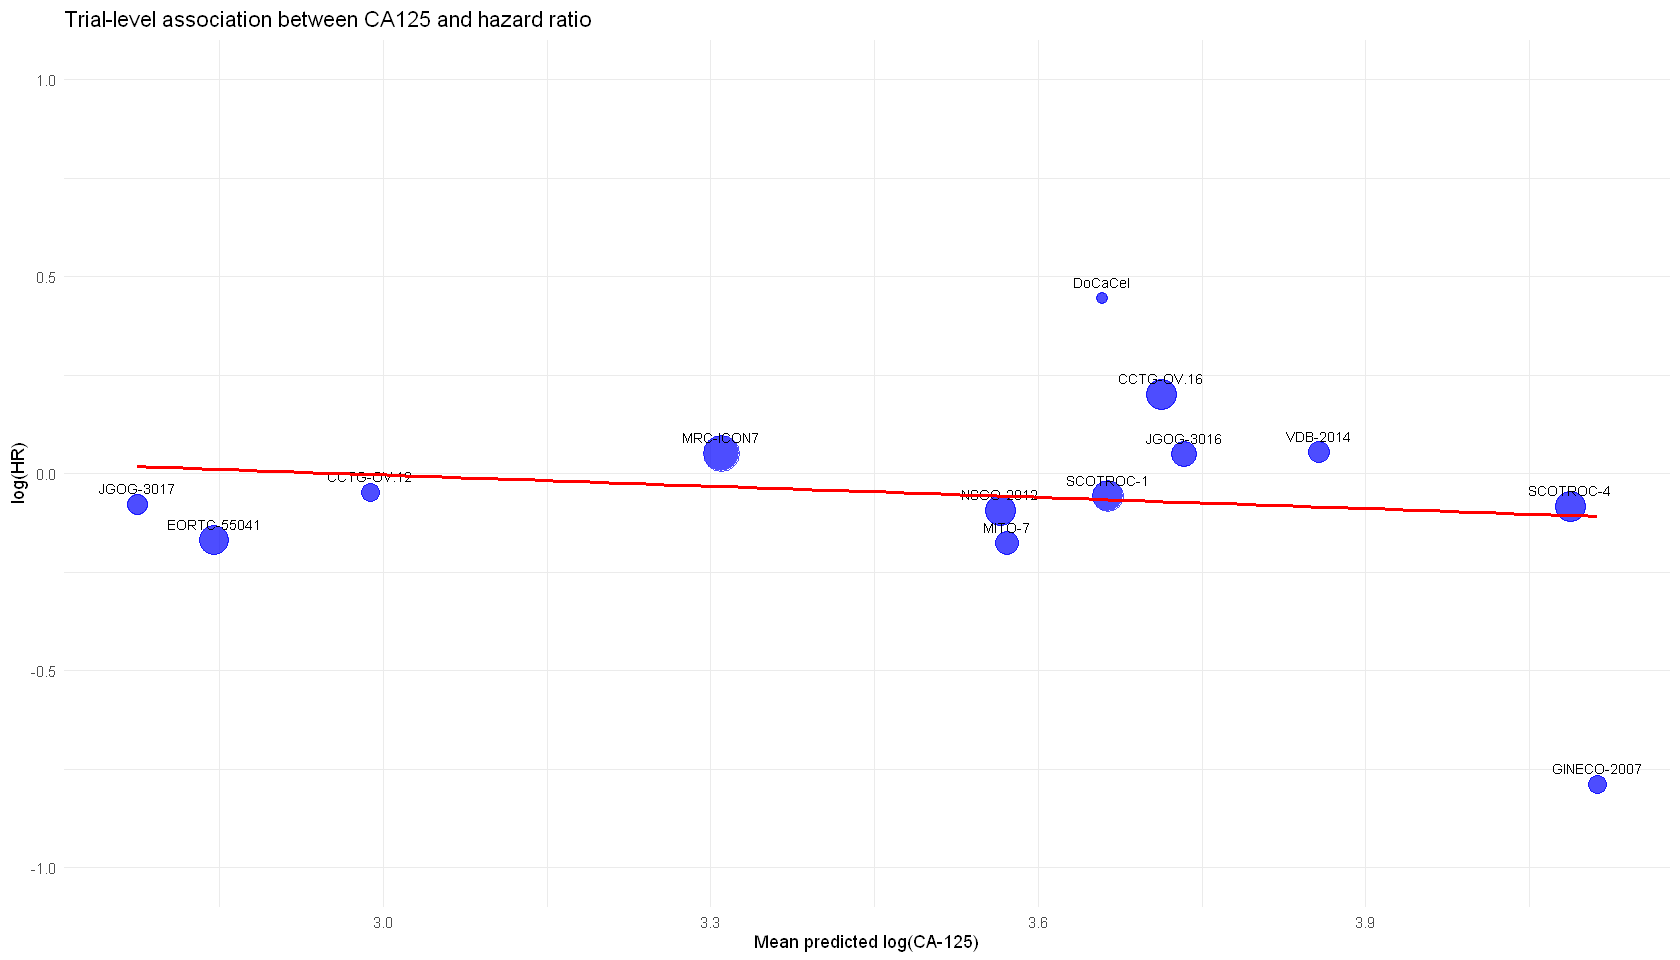

In [20]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary,
       aes(x = mean_log_ca125,
           y = log_hr)) +
  geom_point(aes(size = n_events), color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "log(HR)",
    title = "Trial-level association between CA125 and hazard ratio"
  ) +
  ylim(-1, 1)

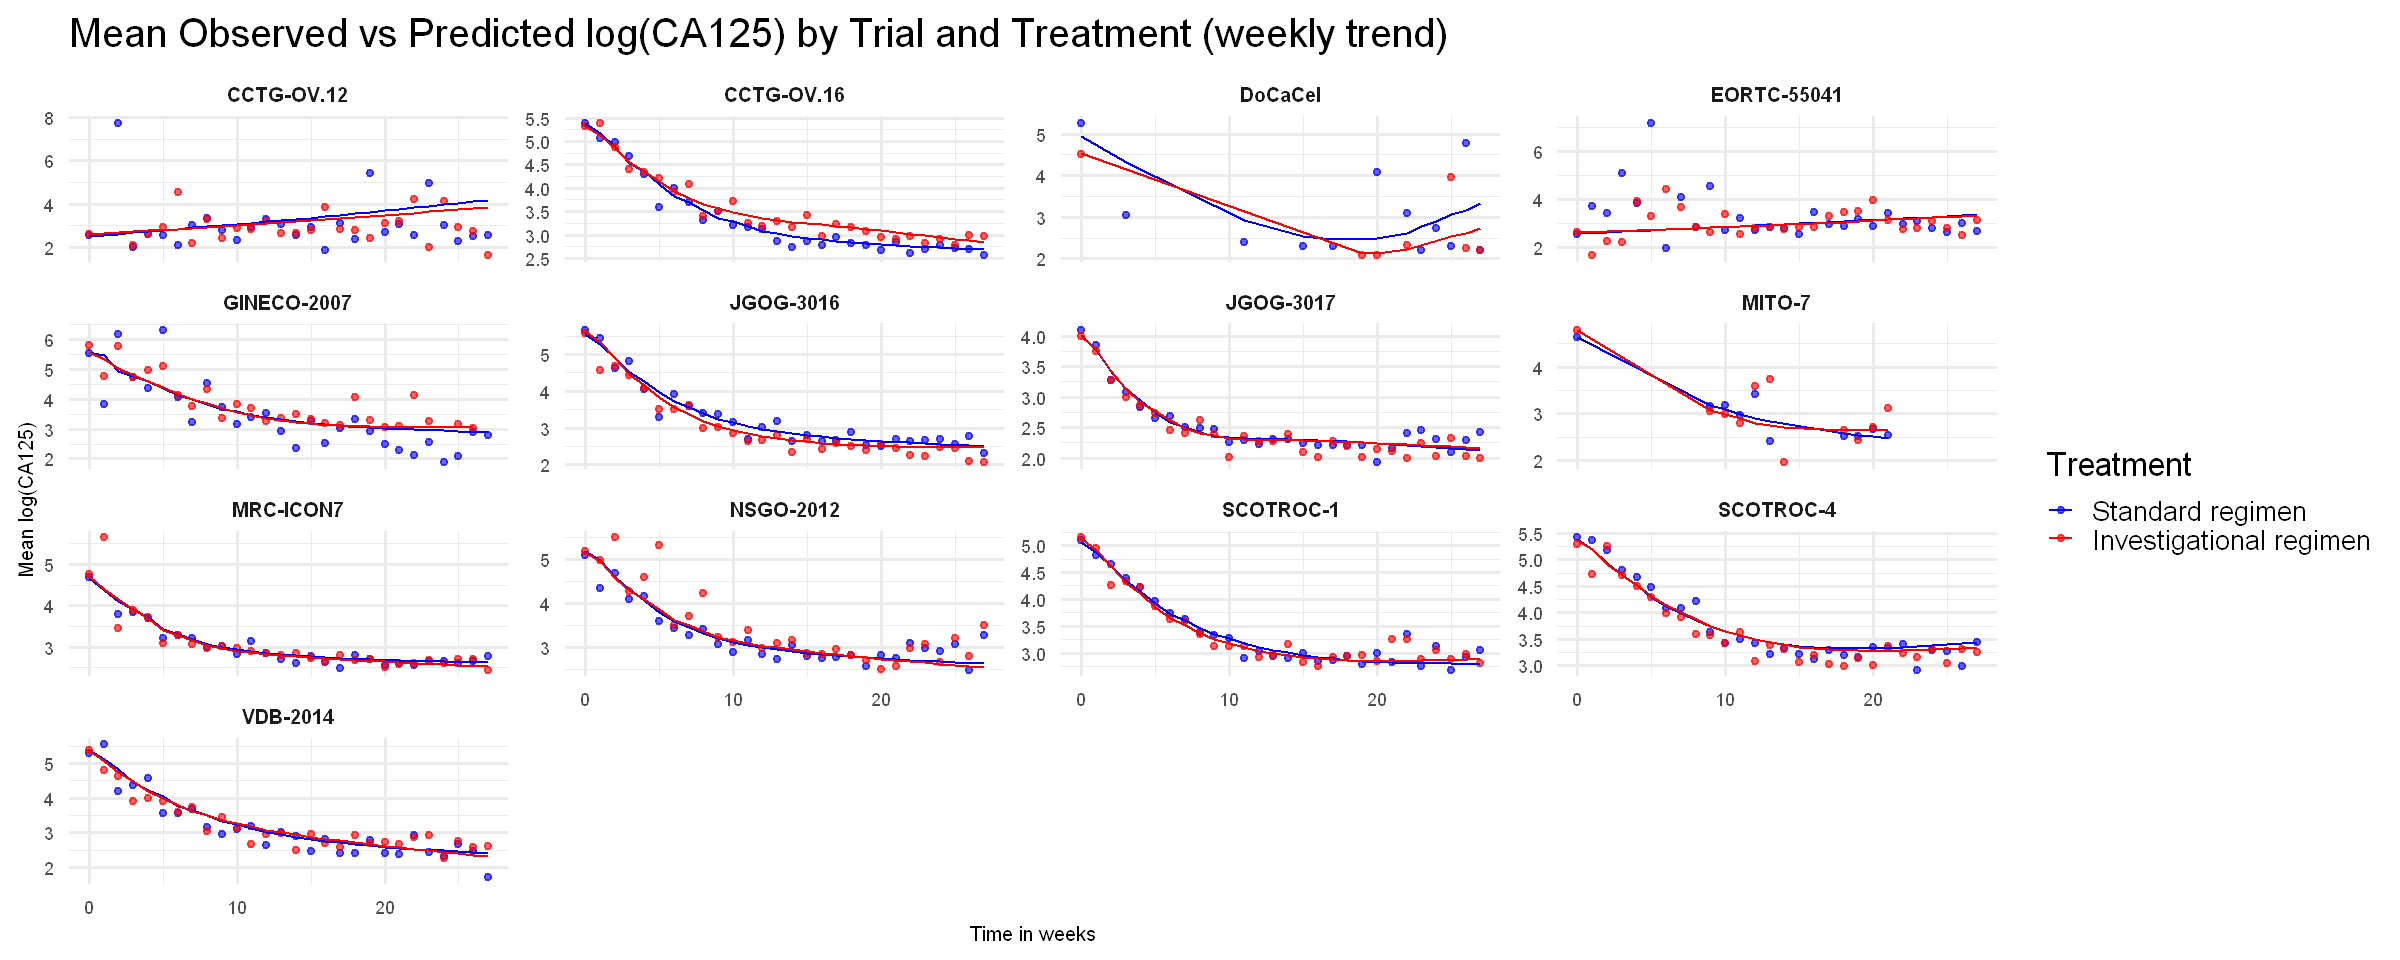

In [21]:
# Comparison between real trajectories and predicited ones
options(repr.plot.width = 20, repr.plot.height = 8)
trial_weekly_predictions %>%
  mutate(trt = factor(trt, levels = c(0, 1),
                        labels = c("Standard regimen", "Investigational regimen")))%>% 
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = log_ca125_week),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = log_ca125_pred_week),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(name= "Treatment",values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

**Compute $R^2_{trial}$**
- One joint model by trial then extract log(HR) associated with "trt_bin"
- Predict average log(CA-125) trajectory for treatment group and control group using joint model\
1) **Nadir:** $\Delta = min_t(\hat{Y}_{trt}) - min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta$\
              $\Delta_r = min_t(\hat{Y}_{trt})/min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta log(\Delta_r)$ 
2) **Time to nadir:** $\Delta_t = \text{time to }min_t(\hat{Y}_{trt}) - \text{time to }min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta_t$
3) **Difference of slopes:** $S_i=\frac{\hat{Y}(t_i) -\hat{Y}(t_i-1)}{t_i - t_i-1}$, $t_i \in \{30,60,90,120,150,180\}$, $log(HR) = \alpha + \beta (S_{i_{trt}}- S_{i_{ctrl}})$, $log(HR) = \alpha + \beta log(S_{i_{trt}}/ S_{i_{ctrl}})$
4) **Area between curves:** $AUC\approx \sum_{i=1}^{n-1} (t_{i+1} - t_i)\,\frac{(\hat{Y_{trt}}(t_i) -\hat{Y_{ctrl}}(t_i) )+ (\hat{Y}_{trt}(t_{i+1}) -\hat{Y}_{ctrl}(t_{i+1}))}{2}$, $log (HR)= \alpha + \beta AUC$
5) **Reduction from baseline:** $R_i=\frac{\hat{Y}(t_0) - \hat{y}(t_i)}{\hat{Y}(t_0)}$, $log (HR)= \alpha + \beta (R_{i_{trt}} - R_{i_{ctrl}})$,$log (HR)= \alpha + \beta log(R_{i_{trt}}/R_{i_{ctrl}})$
6) **Difference**: $log(HR)= \alpha +\beta (\hat{Y}(t_i)_{trt} - \hat{Y}(t_i)_{ctrl})$, $log(HR)= \alpha +\beta log(\hat{Y}(t_i)_{trt}/ \hat{Y}(t_i)_{ctrl})$




In [22]:
# Format
trial_results_ <- trial_results %>%
  mutate(

    # % reduction
    delta_pct1 = map_dbl(pct_m1, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_pct2 = map_dbl(pct_m2, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_pct3 = map_dbl(pct_m3, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_pct4 = map_dbl(pct_m4, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_pct5 = map_dbl(pct_m5, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_pct6 = map_dbl(pct_m6, ~ .x[[1]]$trt - .x[[1]]$ctrl),

    ratio_pct1 = map_dbl(pct_m1, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_pct2 = map_dbl(pct_m2, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_pct3 = map_dbl(pct_m3, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_pct4 = map_dbl(pct_m4, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_pct5 = map_dbl(pct_m5, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_pct6 = map_dbl(pct_m6, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),

    # Slopes
    delta_slope1 = map_dbl(slope_m1, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_slope2 = map_dbl(slope_m2, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_slope3 = map_dbl(slope_m3, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_slope4 = map_dbl(slope_m4, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_slope5 = map_dbl(slope_m5, ~ .x[[1]]$trt - .x[[1]]$ctrl),
    delta_slope6 = map_dbl(slope_m6, ~ .x[[1]]$trt - .x[[1]]$ctrl),

    ratio_slope1 = map_dbl(slope_m1, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_slope2 = map_dbl(slope_m2, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_slope3 = map_dbl(slope_m3, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_slope4 = map_dbl(slope_m4, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_slope5 = map_dbl(slope_m5, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),
    ratio_slope6 = map_dbl(slope_m6, ~ log(.x[[1]]$trt / .x[[1]]$ctrl)),

    # Absolute CA125 values
    abs1 = map_dbl(diff_m1, ~ .x$trt - .x$ctrl),
    abs2 = map_dbl(diff_m2, ~ .x$trt - .x$ctrl),
    abs3 = map_dbl(diff_m3, ~ .x$trt - .x$ctrl),
    abs4 = map_dbl(diff_m4, ~ .x$trt - .x$ctrl),
    abs5 = map_dbl(diff_m5, ~ .x$trt - .x$ctrl),
    abs6 = map_dbl(diff_m6, ~ .x$trt - .x$ctrl),

    relativ1 = map_dbl(diff_m1, ~ log(.x$trt / .x$ctrl)),
    relativ2 = map_dbl(diff_m2, ~ log(.x$trt / .x$ctrl)),
    relativ3 = map_dbl(diff_m3, ~ log(.x$trt / .x$ctrl)),
    relativ4 = map_dbl(diff_m4, ~ log(.x$trt / .x$ctrl)),
    relativ5 = map_dbl(diff_m5, ~ log(.x$trt / .x$ctrl)),
    relativ6 = map_dbl(diff_m6, ~ log(.x$trt / .x$ctrl))
    )

Warning message:
"There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `ratio_slope5 = map_dbl(slope_m5,
  ~log(.x[[1]]$trt/.x[[1]]$ctrl))`.
Caused by warning in `log()`:
! Production de NaN
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning."


In [23]:
# Compute r2

model_formulas <- list(
  nadir = logHR ~ delta_nadir,
  time_nadir = logHR ~ delta_time_nadir,
  auc = logHR ~ delta_auc,
  delta_kelim = logHR ~ delta_kelim,
  ratio_kelim = logHR ~ ratio_kelim,

  delta_pct1 = logHR ~ delta_pct1,
  ratio_pct1 = logHR ~ ratio_pct1,
  delta_pct2 = logHR ~ delta_pct2,
  ratio_pct2 = logHR ~ ratio_pct2,
  delta_pct3 = logHR ~ delta_pct3,
  ratio_pct3 = logHR ~ ratio_pct3,
  delta_pct4 = logHR ~ delta_pct4,
  ratio_pct4 = logHR ~ ratio_pct4,
  delta_pct5 = logHR ~ delta_pct5,
  ratio_pct5 = logHR ~ ratio_pct5,
  delta_pct6 = logHR ~ delta_pct6,
  ratio_pct6 = logHR ~ ratio_pct6,

  delta_slope1 = logHR ~ delta_slope1,
  ratio_slope1 = logHR ~ ratio_slope1,
  delta_slope2 = logHR ~ delta_slope2,
  ratio_slope2 = logHR ~ ratio_slope2,
  delta_slope3 = logHR ~ delta_slope3,
  ratio_slope3 = logHR ~ ratio_slope3,
  delta_slope4 = logHR ~ delta_slope4,
  ratio_slope4 = logHR ~ ratio_slope4,
  delta_slope5 = logHR ~ delta_slope5,
  delta_slope6 = logHR ~ delta_slope6,

  abs1 = logHR ~ abs1,
  relativ1 = logHR ~ relativ1,
  abs2 = logHR ~ abs2,
  relativ2 = logHR ~ relativ2,
  abs3 = logHR ~ abs3,
  relativ3 = logHR ~ relativ3,
  abs4 = logHR ~ abs4,
  relativ4 = logHR ~ relativ4,
  abs5 = logHR ~ abs5,
  relativ5 = logHR ~ relativ5,
  abs6 = logHR ~ abs6,
  relativ6 = logHR ~ relativ6
)

#Boostrap
set.seed(123)
B <- 2000
n <- nrow(trial_results_)
boot_r2 <- matrix(NA_real_,nrow = B,ncol = length(model_formulas))
colnames(boot_r2) <- names(model_formulas)
for (b in seq_len(B)) {
  idx <- sample.int(n,size = n,replace = TRUE)
  data_b <- trial_results_[idx, ]
  boot_r2[b, ] <- get_r2_models(data_b)
}
boot_summary <- data.frame(
  model = colnames(boot_r2),
  R2 = colMeans(boot_r2,na.rm = TRUE),
  R2_low = apply(boot_r2,2,quantile,probs = 0.025,na.rm = TRUE),
  R2_high = apply(boot_r2,2,quantile,probs = 0.975,na.rm = TRUE)
)
boot_summary

Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


,model,R2,R2_low,R2_high
,<chr>,<dbl>,<dbl>,<dbl>
nadir,nadir,0.20398093,1.416134e-04,0.7539695
time_nadir,time_nadir,0.02535929,0.000000e+00,0.1726703
auc,auc,0.25162040,2.670226e-02,0.6258688
delta_kelim,delta_kelim,0.20776117,1.004146e-04,0.8942028
ratio_kelim,ratio_kelim,0.22480159,1.423853e-04,0.9571522
delta_pct1,delta_pct1,0.13592816,2.608828e-04,0.6134103
ratio_pct1,ratio_pct1,0.15014728,3.175907e-04,0.5119745
delta_pct2,delta_pct2,0.13836500,1.364149e-04,0.5406660
ratio_pct2,ratio_pct2,0.20679782,4.283860e-03,0.6321846


Leave-one-trial-out

In [24]:

# # ----------------------------------
# # leave-one-study-out
# # ----------------------------------

# B <- 1000

# loso_boot_results <- list()

# for(trial_out in unique(trial_results_$trialid)) {

#   cat("Leaving out:", trial_out, "\n")

#   df_loso <- subset(
#     trial_results,
#     trialid != trial_out
#   )

#   model_results <- lapply(names(model_formulas), function(model_name){

#     r2_boot <- replicate(B, {

#       idx <- sample(
#         seq_len(nrow(df_loso)),
#         size = nrow(df_loso),
#         replace = TRUE
#       )

#       boot_df <- df_loso[idx, ]

#       fit <- lm(
#         model_formulas[[model_name]],
#         data = boot_df,
#         weights = n
#       )

#       suppressWarnings(summary(fit)$r.squared)
#     })

#     data.frame(
#       left_out_trial = trial_out,
#       summary = model_name,
#       R2 = mean(r2_boot),
#       CI_low = quantile(r2_boot, 0.025),
#       CI_high = quantile(r2_boot, 0.975)
#     )
#   })

#   loso_boot_results[[trial_out]] <- bind_rows(model_results)
# }
# loso_boot_r2 <- bind_rows(loso_boot_results)

In [25]:
# plot_df <- loso_boot_r2 %>%
#   filter(summary %in% c(
#     "pct3",
#     "abs3",
#     "slope3",
#     "pct6",
#     "abs6",
#     "slope6",
#     "delta_kelim"
#   )) %>%
#   mutate(
#     summary = factor(
#       summary,
#       levels = c(
#         "pct3",
#         "pct6",
#         "abs3",
#         "abs6",
#         "slope3",
#         "slope6",
#         "delta_kelim"
#       ),
#       labels = c(
#         "Reduction from baseline (3 months)",
#         "Reduction from baseline (6 months)",
#         "Absolute difference (3 months)",
#         "Absolute difference (6 months)",
#         "Difference in slopes (3 months)",
#         "Difference in slopes (6 months)",
#         "KELIM (3 months)"
#       )
#     )
#   )

# ggplot(
#   plot_df,
#   aes(
#     x = reorder(left_out_trial, R2),
#     y = R2
#   )
# ) +
#   geom_segment(
#     aes(
#       xend = left_out_trial,
#       y = 0,
#       yend = R2
#     )
#   ) +
#   geom_point(size = 2.5) +
#   coord_flip() +
#   facet_wrap(~summary, ncol = 3, scales = "fixed") +
#   labs(
#     x = "Trial omitted",
#     y = expression(R^2),
#     title = "Leave-one-study-out sensitivity analysis"
#   ) +
#   theme_bw() +
#   theme(
#     strip.text = element_text(face = "bold"),
#     axis.text.y = element_text(size = 7)
#   )

**No maintenance trials**

In [26]:
#Boostrap for r2 CI
set.seed(123)
n <- nrow(trial_results[-c(1,3,4,9), ])

boot_r2 <- matrix(NA_real_, nrow = B, ncol = length(model_formulas))
colnames(boot_r2) <- names(model_formulas)

for (b in seq_len(B)) {
  idx <- sample.int(n,size = n,replace = TRUE)
  data_b <- trial_results_ [-c(1,3,4,9), ][idx, ]
  boot_r2[b, ] <- get_r2_models(data_b)
}
boot_summary2 <- data.frame(
  model = colnames(boot_r2),
  R2 = colMeans(boot_r2,na.rm = TRUE),
  R2_low = apply(boot_r2,2,quantile,probs = 0.025,na.rm = TRUE),
  R2_high = apply(boot_r2,2,quantile,probs = 0.975,na.rm = TRUE)
)
boot_summary2

Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


,model,R2,R2_low,R2_high
,<chr>,<dbl>,<dbl>,<dbl>
nadir,nadir,0.25498151,2.331730e-04,0.8574424
time_nadir,time_nadir,0.03958524,0.000000e+00,0.2658985
auc,auc,0.35217994,4.443569e-02,0.9093158
delta_kelim,delta_kelim,0.26560495,8.269844e-05,0.9864435
ratio_kelim,ratio_kelim,0.28511271,2.230056e-04,0.9946869
delta_pct1,delta_pct1,0.16059037,1.624148e-04,0.7876712
ratio_pct1,ratio_pct1,0.20741942,7.485956e-04,0.6800520
delta_pct2,delta_pct2,0.26537974,1.850034e-02,0.8036585
ratio_pct2,ratio_pct2,0.28048683,1.291371e-02,0.7848049


**Same trials as KELIM ones**

In [27]:

#Boostrap for r2 CI
set.seed(123)
n <- nrow(trial_results[-c(1,3,4,8,13), ])

boot_r2 <- matrix(NA_real_, nrow = B, ncol = length(model_formulas))
colnames(boot_r2) <- names(model_formulas)

for (b in seq_len(B)) {
  idx <- sample.int(n,size = n,replace = TRUE)
  data_b <- trial_results_ [-c(1,3,4,8,13), ][idx, ]
  boot_r2[b, ] <- get_r2_models(data_b)
}
boot_summary3 <- data.frame(
  model = colnames(boot_r2),
  R2 = colMeans(boot_r2,na.rm = TRUE),
  R2_low = apply(boot_r2,2,quantile,probs = 0.025,na.rm = TRUE),
  R2_high = apply(boot_r2,2,quantile,probs = 0.975,na.rm = TRUE)
)
boot_summary3

Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(model):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


,model,R2,R2_low,R2_high
,<chr>,<dbl>,<dbl>,<dbl>
nadir,nadir,0.24327885,2.035703e-04,0.8775764
time_nadir,time_nadir,0.07505733,0.000000e+00,0.5167624
auc,auc,0.34335639,5.202906e-02,0.9573896
delta_kelim,delta_kelim,0.18875173,1.265800e-04,0.7995936
ratio_kelim,ratio_kelim,0.20542786,1.317181e-04,0.8769520
delta_pct1,delta_pct1,0.20441470,2.202706e-04,0.7556690
ratio_pct1,ratio_pct1,0.20525275,1.187481e-04,0.8220877
delta_pct2,delta_pct2,0.25302844,2.440351e-02,0.8292797
ratio_pct2,ratio_pct2,0.26293430,3.005429e-02,0.7959703


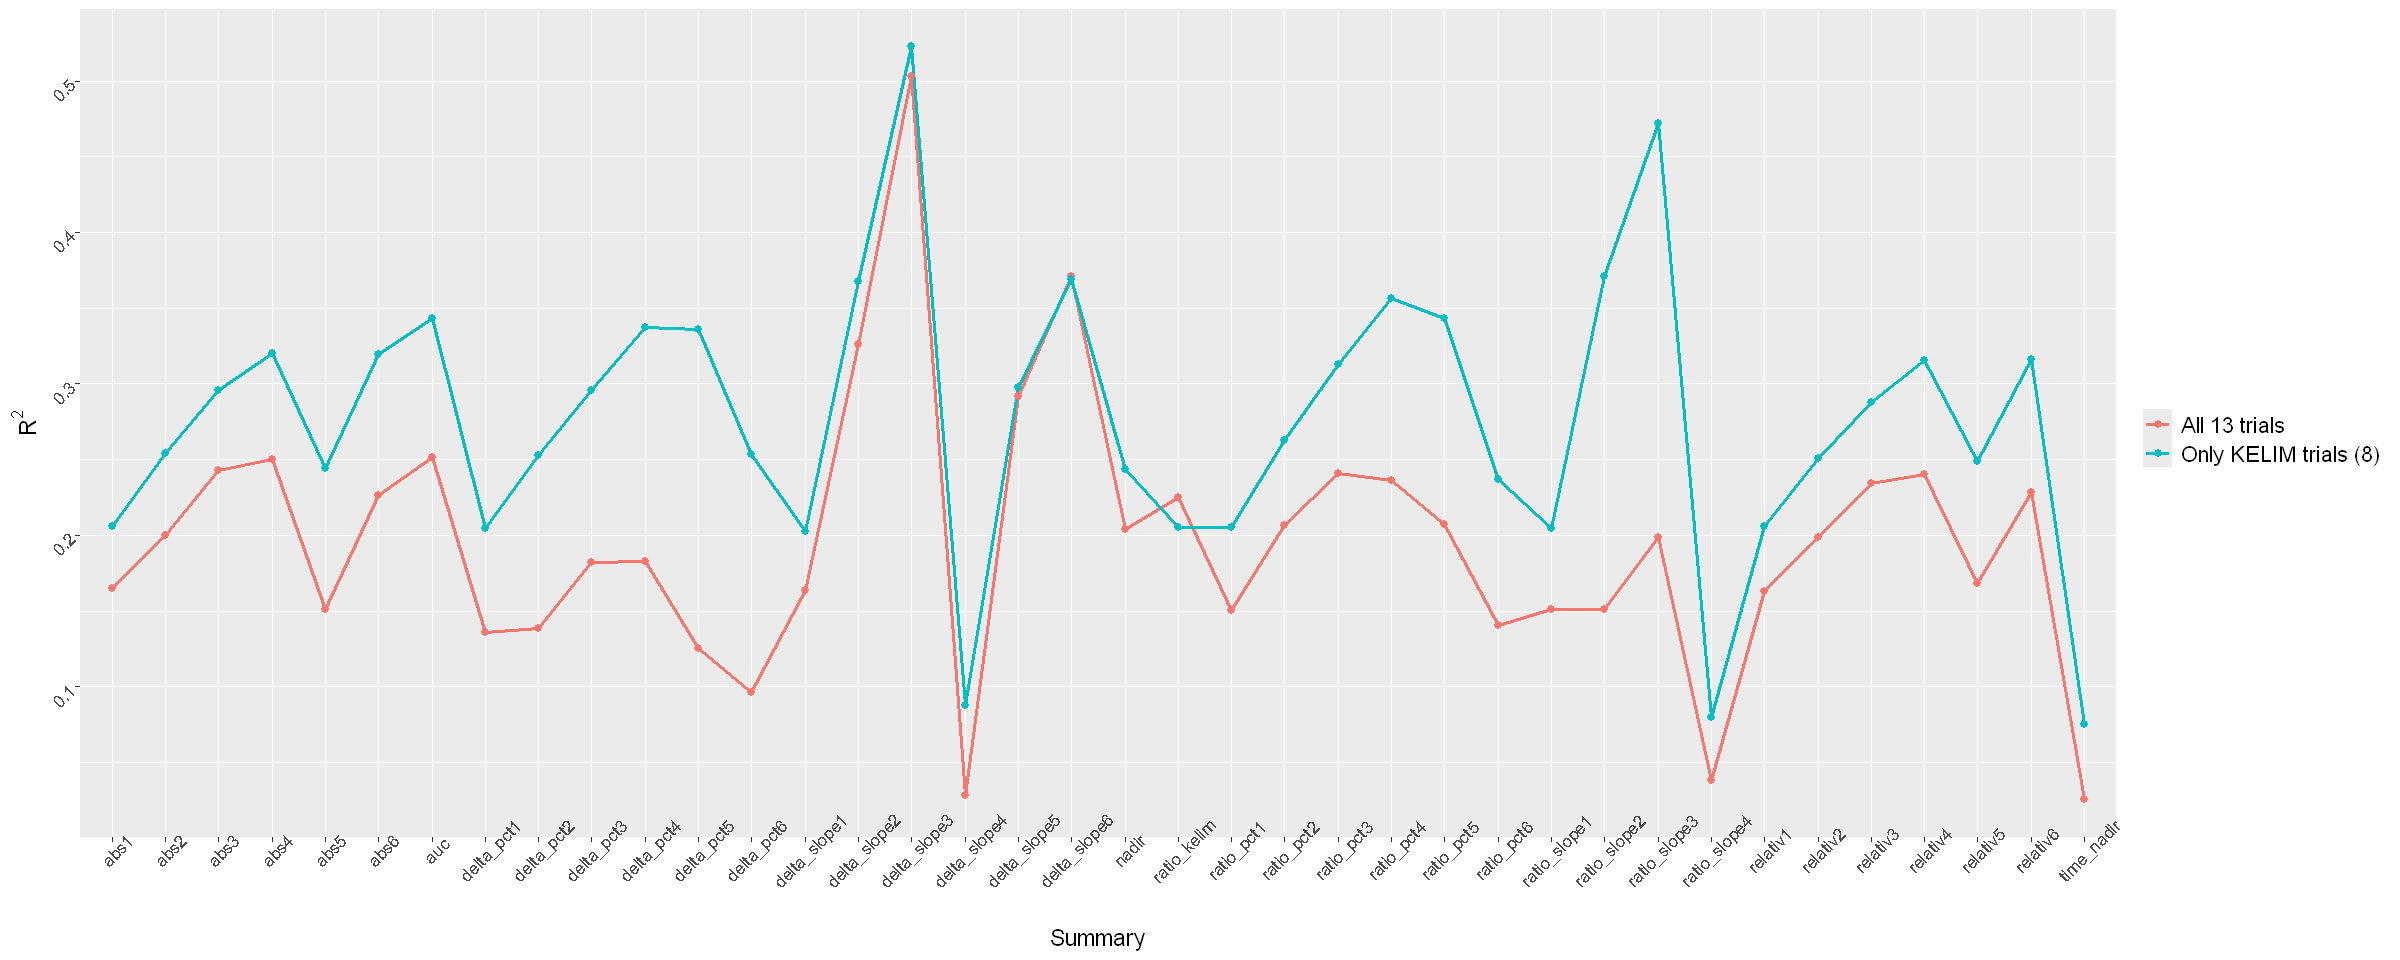

In [28]:
ggplot(rbind(
  boot_summary %>% rownames_to_column("summary") %>% filter(!summary %in% c("beta_kelim", "delta_kelim"))%>% mutate(dataset = "All 13 trials"),
  boot_summary3 %>% rownames_to_column("summary") %>% filter(!summary %in% c("beta_kelim", "delta_kelim"))%>% mutate(dataset = "Only KELIM trials (8)")
),
       aes(x = summary,
           y = R2,
           color = dataset,
           group = dataset)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(
    axis.title = element_text(size = 14),   
    axis.text = element_text(size = 10,angle = 45),    
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 13),
    plot.title = element_text(size = 18)
  ) +
  labs(x = "Summary",
       y = expression(R^2),
       color = "")

# Survival-continuous surrogacy evaluation for KELIM : copula model

In [29]:
kelim_data <- kelim %>%
  filter(!is.na(KELIM_continuous),!is.na(PFS_time))%>% 
  mutate(trialid_num = as.numeric(as.factor(trial_name)), 
         id_num=as.numeric(as.factor(id)),
         pfs_time_d=as.numeric(PFS_time*365.2425 ),
         pfs_statut=factor(ifelse(PFS_status=='Yes', 1, 0), levels=c(0,1))
         ) %>%
  mutate(
    id_num = unname(id_num),
    trt_bin = unname(trt_bin),
    trialid_num = unname(trialid_num),
    pfs_time_d = unname(pfs_time_d),
    pfs_statut = unname(pfs_statut),
    KELIM_continuous = unname(KELIM_continuous)
  )
kelim_data$trt_bin <- as.numeric(as.character(kelim_data$trt_bin))
kelim_data$pfs_statut <- as.numeric(as.character(kelim_data$pfs_statut))
print(paste0(c("Number of measurements with KELIM data:", nrow(kelim_data), 
"\nNumber of patients with KELIM data:", length(unique(kelim_data$id)))))

[1] "Number of measurements with KELIM data:"
[2] "5883"                                   
[3] "\nNumber of patients with KELIM data:"  
[4] "5883"                                   


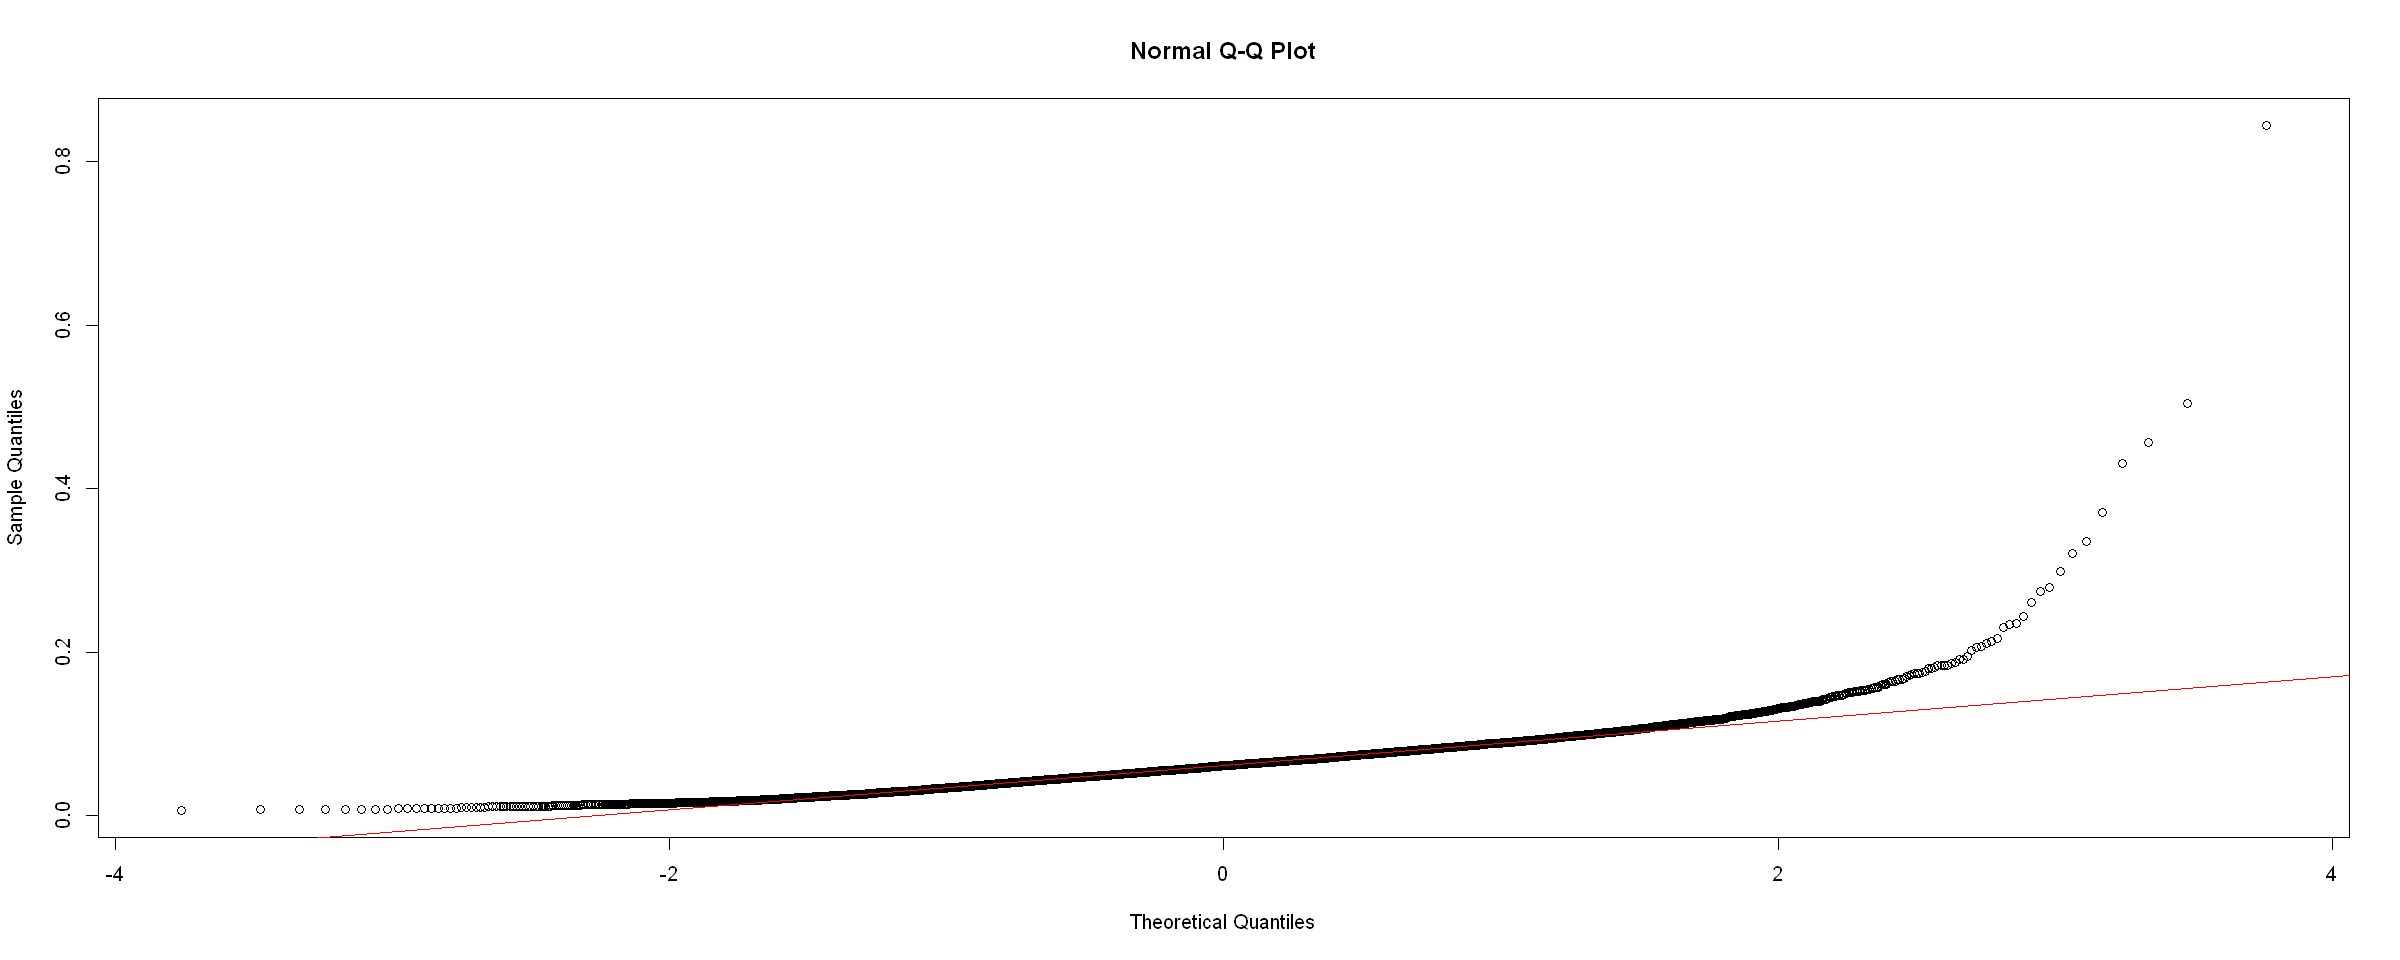

In [30]:
qqnorm(kelim$KELIM_continuous)
qqline(kelim$KELIM_continuous, col="red")

In [31]:
survcont_plackett_w<-MetaAnalyticSurvCont(
  data=kelim_data,
  true=pfs_time_d,
  trueind=pfs_statut,
  surrog=KELIM_continuous,
  trt=trt_bin,
  center=trialid_num,
  trial=trialid_num,
  patientid=id_num,
  copula="Plackett",
  adjustment="weighted"
)
survcont_plackett_w$nlm.output$code

Fitting the model with Plackett copula...



[1] 2

In [32]:
print(survcont_plackett_w)

Surrogacy measures with 95% confidence interval 

Individual level surrogacy:  

Spearmans rho :  0.4565 [ 0.4335 ; 0.4796 ] 

Trial level surrogacy:  

R Square:  0.4593 [ 0.0000 ; 1.0000 ] 

Estimated treatment effects on surrogate (surro_est) and survival (surv_est) endpoint: 

 center     surv_est    surv_se    surro_est    surro_se sample_size
      1  0.002721574 0.08070452 -0.003107647 0.001908738         699
      2  0.013467732 0.21192123 -0.007736377 0.005919058          96
      3 -0.278172919 0.10949339  0.007061525 0.003942289         510
      4  0.063548996 0.15913101  0.003677174 0.003196164         554
      5  0.030120031 0.06240129  0.000396086 0.001369127        1442
      6  0.112155822 0.08595292 -0.003835926 0.002245621         680
      7 -0.011138718 0.07830125  0.002831010 0.002073187        1019
      8 -0.049708687 0.07900071  0.001661804 0.001825067         883


`geom_smooth()` using formula = 'y ~ x'


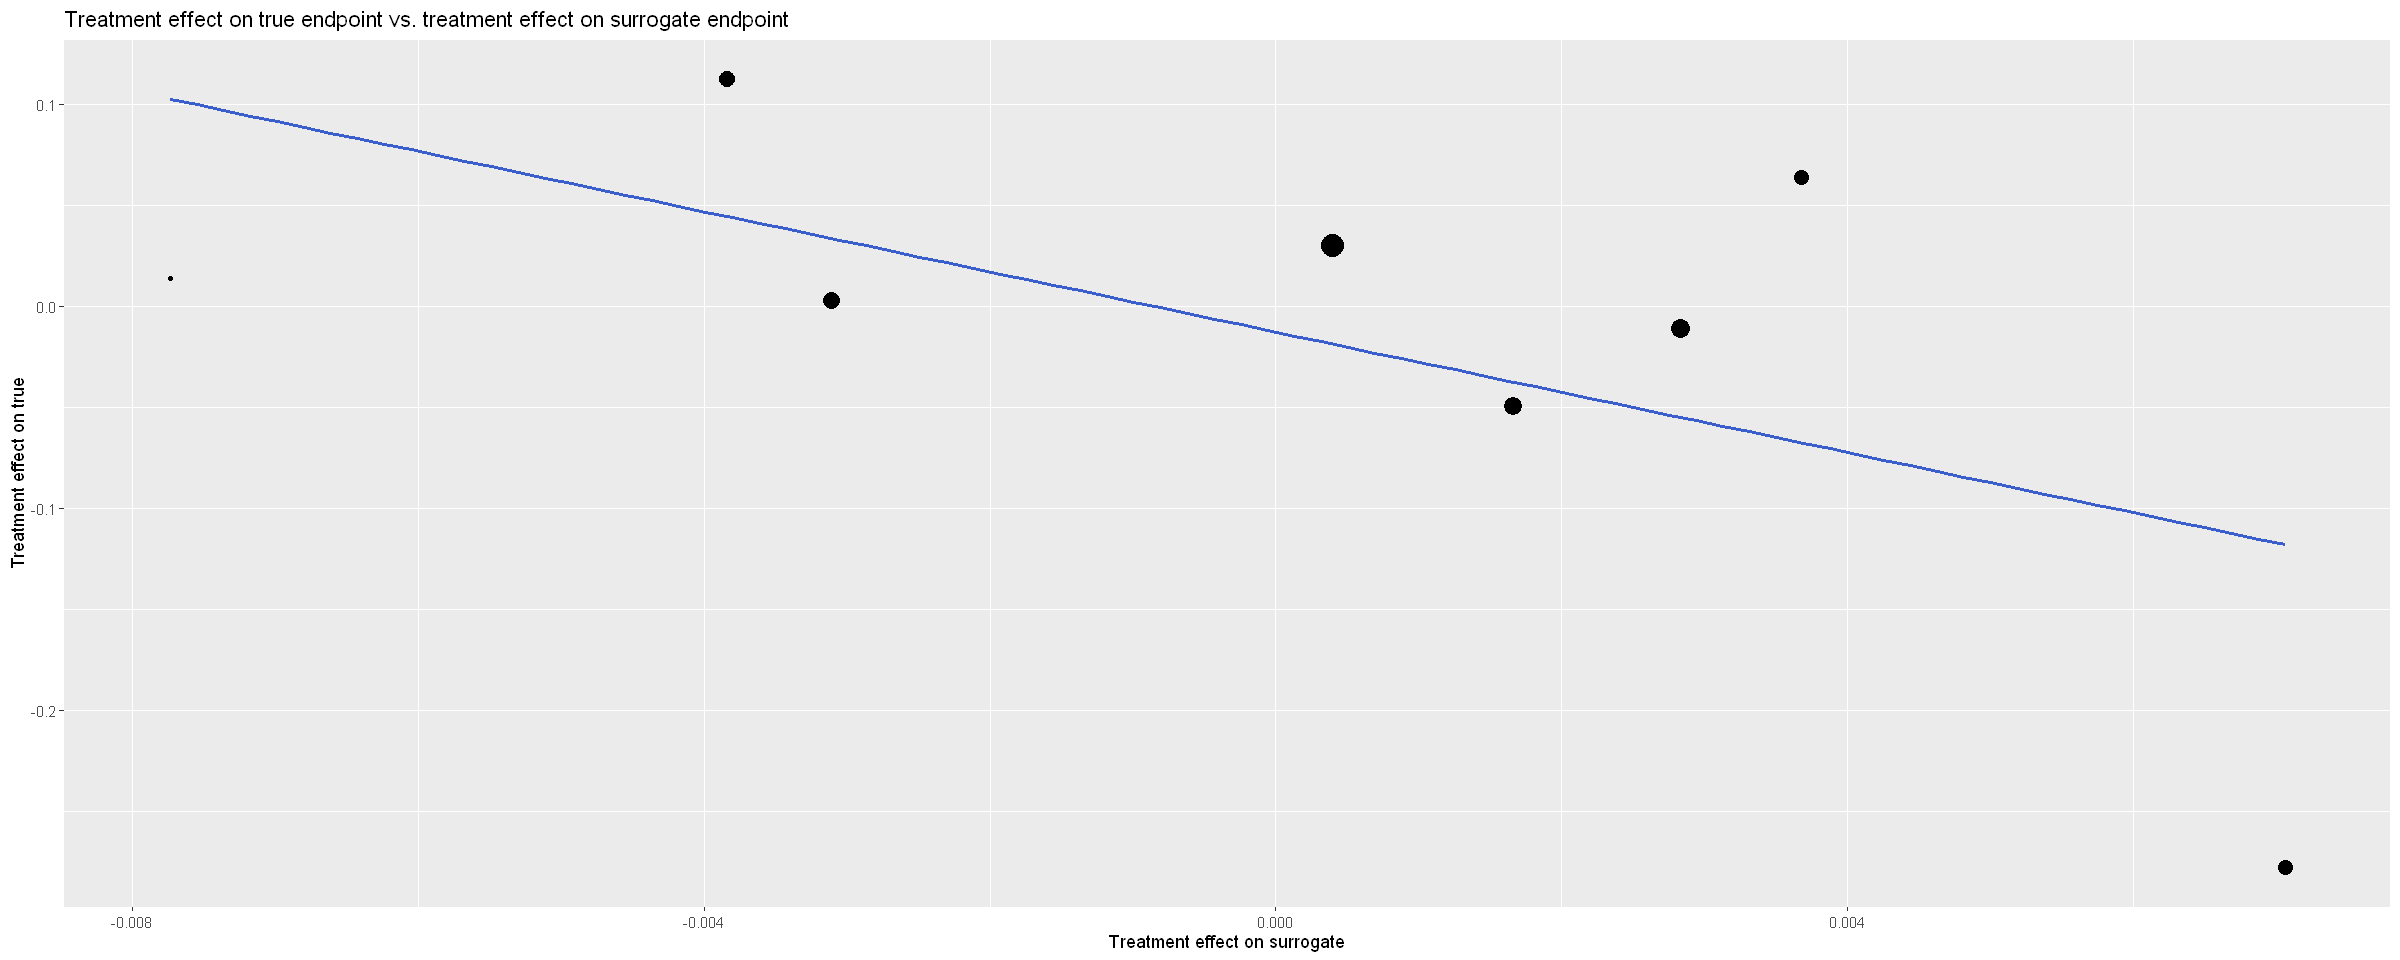

In [33]:
plot(survcont_plackett_w)

In [ ]:
#Bootstrap for R2 CI
set.seed(123)
n <- nrow(kelim_data)

boot_r2 <- matrix(NA_real_, nrow = 100, ncol = 1)
colnames(boot_r2) <- "plackett_weighted"

for (b in seq_len(100)) {
  idx <- sample.int(n,size = n,replace = TRUE)
  data_b <- kelim_data[idx, ]
  model <-MetaAnalyticSurvCont(
  data=data_b,
  true=pfs_time_d,
  trueind=pfs_statut,
  surrog=KELIM_continuous,
  trt=trt_bin,
  center=trialid_num,
  trial=trialid_num,
  patientid=id_num,
  copula="Plackett",
  adjustment="weighted"
)
  boot_r2[b, ] <- model$Trial.R2["R2 Trial (weighted)"][[1]]
}
boot_summary_kelim <- data.frame(
  model = colnames(boot_r2),
  R2 = colMeans(boot_r2,na.rm = TRUE),
  R2_low = apply(boot_r2,2,quantile,probs = 0.025,na.rm = TRUE),
  R2_high = apply(boot_r2,2,quantile,probs = 0.975,na.rm = TRUE)
)
boot_summary_kelim

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

Fitting the model with Plackett copula...

